### Regresión múltiple: explica una variable dependiente usando varias explicativas

Una variable puede estar correlacionada con Y y no ser significativa en la regresión múltiple.

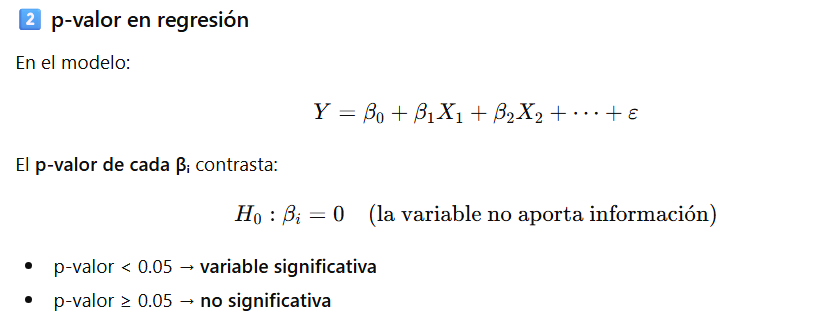

#### CASO 1: TODAS LAS VARIABLES SIGNIFICATIVAS
Dataset: mtcars

Problema real: explicar el consumo (mpg) usando peso y potencia.

In [17]:
### Análisis previo
data(mtcars)

cor(mtcars[, c("mpg", "wt", "hp")])


,mpg,wt,hp
mpg,1.0000000,-0.8676594,-0.7761684
wt,-0.8676594,1.0000000,0.6587479
hp,-0.7761684,0.6587479,1.0000000


Interpretación

mpg–wt: correlación negativa fuerte

mpg–hp: correlación negativa fuerte

In [22]:
### Modelo de regresión múltiple

modelo1 <- lm(mpg ~ wt + hp, data = mtcars)
summary(modelo1)



Call:
lm(formula = mpg ~ wt + hp, data = mtcars)

Residuals:
   Min     1Q Median     3Q    Max 
-3.941 -1.600 -0.182  1.050  5.854 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 37.22727    1.59879  23.285  < 2e-16 ***
wt          -3.87783    0.63273  -6.129 1.12e-06 ***
hp          -0.03177    0.00903  -3.519  0.00145 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.593 on 29 degrees of freedom
Multiple R-squared:  0.8268,	Adjusted R-squared:  0.8148 
F-statistic: 69.21 on 2 and 29 DF,  p-value: 9.109e-12


Interpretación del summary

wt

p-valor < 0.001 ✅

A mayor peso → menor consumo

hp

p-valor < 0.01 ✅

A mayor potencia → menor consumo

R² alto (~0.83) → buen ajuste

Conclusión teórica

Ambas variables aportan información relevante al modelo.

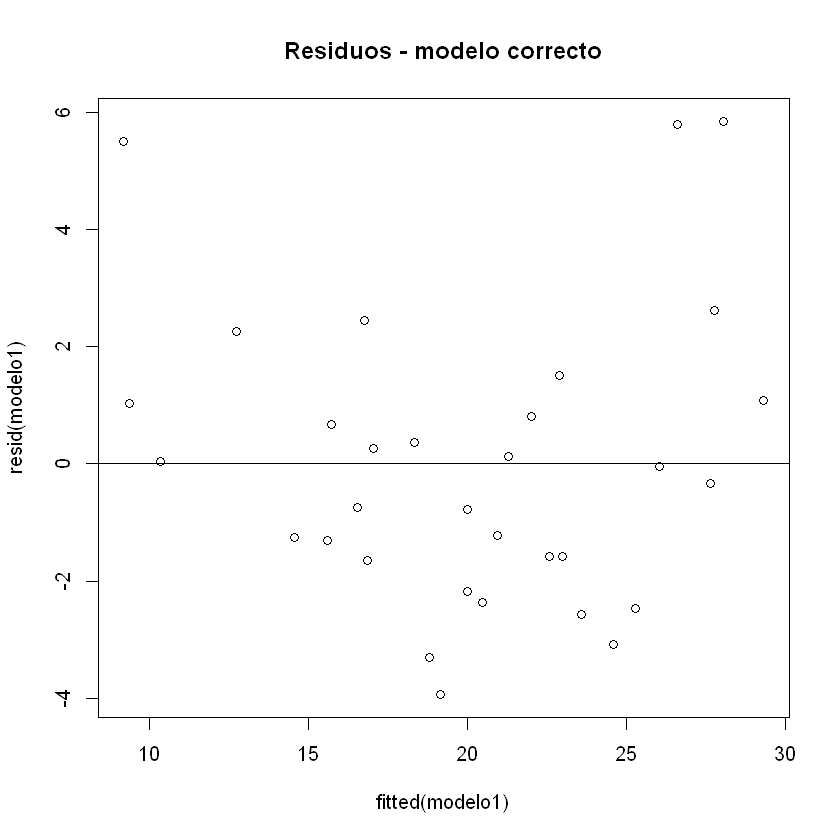

In [27]:
###Gráfico de residuos

plot(fitted(modelo1), resid(modelo1),
     main="Residuos - modelo correcto")
abline(h=0)


Residuos aleatorios → modelo adecuado

#### CASO 2: CORRELACIÓN ALTA PERO VARIABLE NO SIGNIFICATIVA
Multicolinealidad

Añadimos disp (cilindrada).

In [32]:
modelo2 <- lm(mpg ~ wt + hp + disp, data = mtcars)
summary(modelo2)



Call:
lm(formula = mpg ~ wt + hp + disp, data = mtcars)

Residuals:
   Min     1Q Median     3Q    Max 
-3.891 -1.640 -0.172  1.061  5.861 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 37.105505   2.110815  17.579  < 2e-16 ***
wt          -3.800891   1.066191  -3.565  0.00133 ** 
hp          -0.031157   0.011436  -2.724  0.01097 *  
disp        -0.000937   0.010350  -0.091  0.92851    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.639 on 28 degrees of freedom
Multiple R-squared:  0.8268,	Adjusted R-squared:  0.8083 
F-statistic: 44.57 on 3 and 28 DF,  p-value: 8.65e-11


Resultado típico

wt → significativa

hp → puede perder significancia

disp → NO significativa ❌

📌 Explicación teórica

wt, hp y disp están muy correlacionadas entre sí

El modelo no puede separar sus efectos

In [37]:
library(car)
vif(modelo2)


wt       hp     disp 
4.844618 2.736633 7.324517

Correlación alta entre explicativas ⇒ p-valores poco fiables

#### CASO 3: VARIABLE CORRELACIONADA PERO IRRELEVANTE
Dataset: iris

Objetivo: explicar Sepal.Length.

In [41]:
cor(iris[,1:4])


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.0000000,-0.1175698,0.8717538,0.8179411
Sepal.Width,-0.1175698,1.0000000,-0.4284401,-0.3661259
Petal.Length,0.8717538,-0.4284401,1.0000000,0.9628654
Petal.Width,0.8179411,-0.3661259,0.9628654,1.0000000


Petal.Length muy correlacionada

Sepal.Width débilmente correlacionada

In [44]:
modelo3 <- lm(Sepal.Length ~ Sepal.Width + Petal.Length + Petal.Width,
              data = iris)
summary(modelo3)



Call:
lm(formula = Sepal.Length ~ Sepal.Width + Petal.Length + Petal.Width, 
    data = iris)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.82816 -0.21989  0.01875  0.19709  0.84570 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1.85600    0.25078   7.401 9.85e-12 ***
Sepal.Width   0.65084    0.06665   9.765  < 2e-16 ***
Petal.Length  0.70913    0.05672  12.502  < 2e-16 ***
Petal.Width  -0.55648    0.12755  -4.363 2.41e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3145 on 146 degrees of freedom
Multiple R-squared:  0.8586,	Adjusted R-squared:  0.8557 
F-statistic: 295.5 on 3 and 146 DF,  p-value: < 2.2e-16


Interpretación

Petal.Length → p < 0.001 ✅

Petal.Width → puede NO ser significativa

Sepal.Width → p-valor alto ❌

📌 Conclusión

No todas las variables deben mantenerse, aunque estén en el dataset.

#### CASO 4: VARIABLE NO SIGNIFICATIVA

In [48]:
modelo4 <- lm(mpg ~ wt + cyl, data = mtcars)
summary(modelo4)



Call:
lm(formula = mpg ~ wt + cyl, data = mtcars)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.2893 -1.5512 -0.4684  1.5743  6.1004 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  39.6863     1.7150  23.141  < 2e-16 ***
wt           -3.1910     0.7569  -4.216 0.000222 ***
cyl          -1.5078     0.4147  -3.636 0.001064 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.568 on 29 degrees of freedom
Multiple R-squared:  0.8302,	Adjusted R-squared:  0.8185 
F-statistic: 70.91 on 2 and 29 DF,  p-value: 6.809e-12


wt → significativa

cyl → NO significativa

📌 Interpretación correcta

El número de cilindros no aporta información adicional una vez controlado el peso.

#### CASO 5: p-VALOR SIGNIFICATIVO PERO MODELO INCORRECTO

In [52]:
modelo5 <- lm(pressure ~ temperature, data = pressure)
summary(modelo5)



Call:
lm(formula = pressure ~ temperature, data = pressure)

Residuals:
    Min      1Q  Median      3Q     Max 
-158.08 -117.06  -32.84   72.30  409.43 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -147.8989    66.5529  -2.222 0.040124 *  
temperature    1.5124     0.3158   4.788 0.000171 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 150.8 on 17 degrees of freedom
Multiple R-squared:  0.5742,	Adjusted R-squared:  0.5492 
F-statistic: 22.93 on 1 and 17 DF,  p-value: 0.000171


p-valor ≈ 0.000 ✅

R² alto

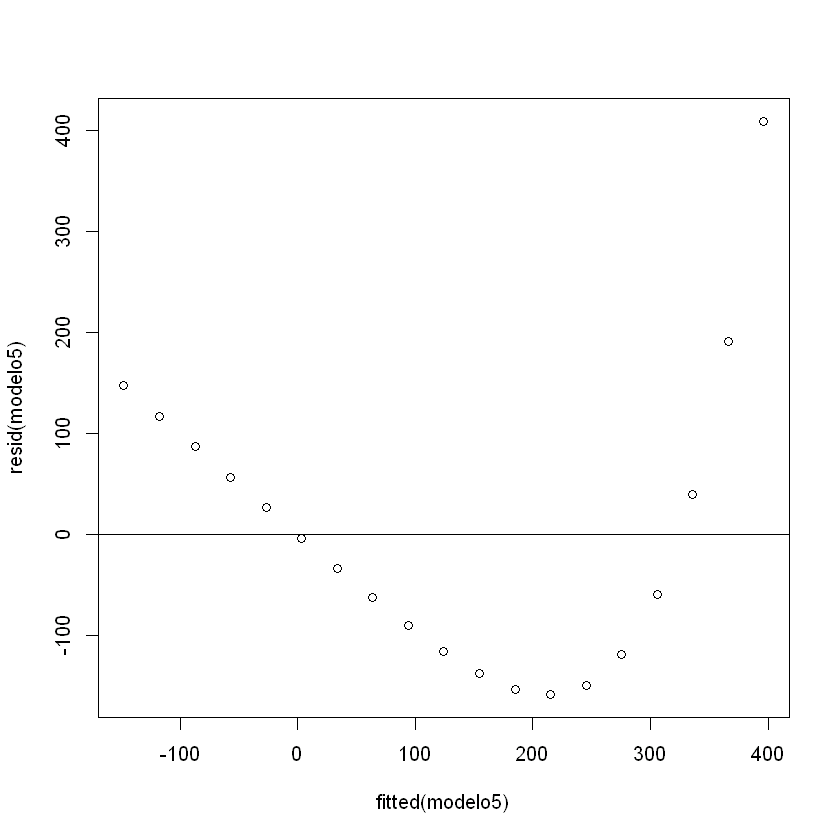

In [55]:
plot(fitted(modelo5), resid(modelo5))
abline(h=0)


Residuos curvos → modelo lineal incorrecto

📌 Mensaje teórico fundamental

Un p-valor pequeño NO garantiza un buen modelo.